# Practical Task 6

1. train a simple classification model;
2. save the trained model artifact;
3. create a FastAPI app with `GET /` and `POST /predict`;
4. test the API locally;
5. prepare a Dockerfile;
6. check Docker commands.


## Step 0. Imports and setup

In [24]:

from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

project_dir = Path("ml-fastapi-docker-fashionmnist")
project_dir.mkdir(exist_ok=True)

train_csv_path = Path("fashion_train.csv")
test_csv_path = Path("fashion_test.csv")

TRAIN_URL = "https://raw.githubusercontent.com/ymattu/fashion-mnist-csv/refs/heads/master/fashion_train.csv"
TEST_URL = "https://raw.githubusercontent.com/ymattu/fashion-mnist-csv/refs/heads/master/fashion_test.csv"

print("Project folder:", project_dir.resolve())
print("Train CSV exists:", train_csv_path.exists())
print("Test CSV exists:", test_csv_path.exists())


Project folder: /Users/boris/PycharmProjects/Machine_learning_course/MNIST-fastapi/ml-fastapi-docker-fashionmnist
Train CSV exists: False
Test CSV exists: False


## Step 1. Train a simple machine learning model

we need:

- a trained model;
- a saved model file.

Here we load FashionMNIST, normalize pixel values, train a simple classifier, and evaluate it on the test split.


In [25]:

def load_or_download_csv(local_path: Path, url: str) -> pd.DataFrame:
    if local_path.exists():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)
    print(f"Local file not found. Downloading from: {url}")
    return pd.read_csv(url)

train_df = load_or_download_csv(train_csv_path, TRAIN_URL)
test_df = load_or_download_csv(test_csv_path, TEST_URL)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())


Local file not found. Downloading from: https://raw.githubusercontent.com/ymattu/fashion-mnist-csv/refs/heads/master/fashion_train.csv
Local file not found. Downloading from: https://raw.githubusercontent.com/ymattu/fashion-mnist-csv/refs/heads/master/fashion_test.csv
Train shape: (1000, 785)
Test shape: (1000, 785)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V776,V777,V778,V779,V780,V781,V782,V783,V784,y
0,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,3,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,91,97,80,78,0,0,0,9
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
3,0,0,0,0,0,0,0,0,1,2,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [26]:

X_train = train_df.drop(columns=["y"]).astype("float32") / 255.0
y_train = train_df["y"].astype("int64")

X_test = test_df.drop(columns=["y"]).astype("float32") / 255.0
y_test = test_df["y"].astype("int64")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (1000, 784)
y_train: (1000,)
X_test: (1000, 784)
y_test: (1000,)


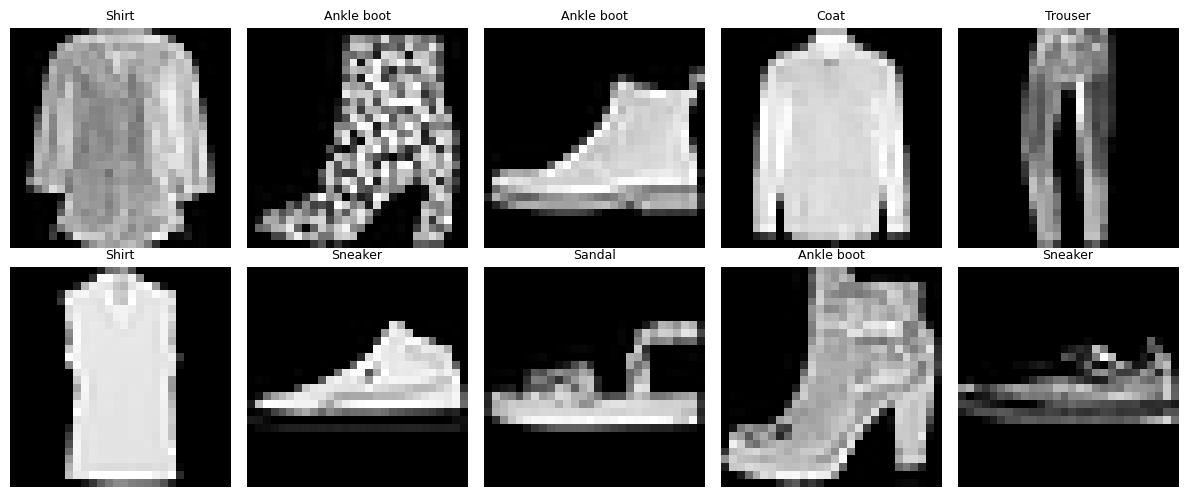

In [27]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    image = X_train.iloc[idx].to_numpy().reshape(28, 28)
    label = int(y_train.iloc[idx])
    ax.imshow(image, cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [28]:

model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train)
test_predictions = model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Test accuracy: {test_accuracy:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, test_predictions, target_names=CLASS_NAMES))


Test accuracy: 0.8140

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.81      0.77        91
     Trouser       0.98      0.93      0.96        92
    Pullover       0.64      0.85      0.73        91
       Dress       0.84      0.88      0.86       105
        Coat       0.74      0.60      0.66        99
      Sandal       0.90      0.86      0.88       105
       Shirt       0.56      0.44      0.49        99
     Sneaker       0.87      0.85      0.86        94
         Bag       0.97      0.97      0.97       115
  Ankle boot       0.87      0.93      0.90       109

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000


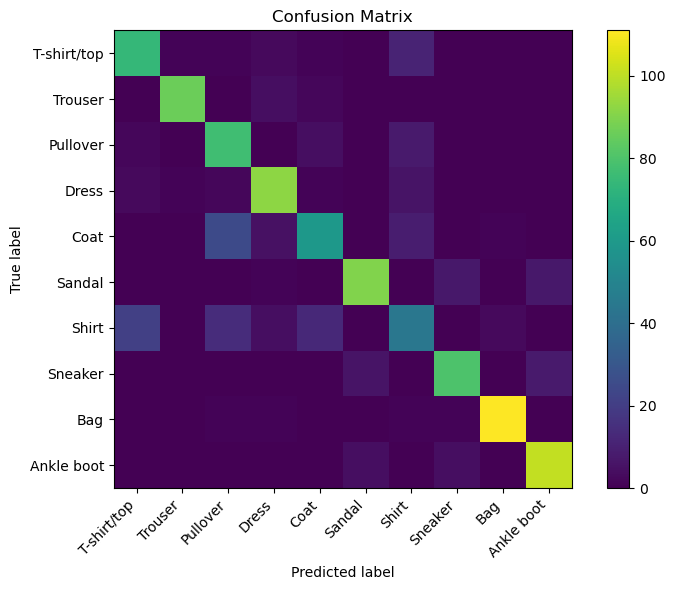

In [29]:

cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Save the trained model artifact

will later be loaded by the API service.


In [30]:

model_path = project_dir / "model.joblib"
class_names_path = project_dir / "class_names.json"

joblib.dump(model, model_path)
class_names_path.write_text(json.dumps(CLASS_NAMES, indent=2), encoding="utf-8")

print("Saved model:", model_path.resolve())
print("Saved class names:", class_names_path.resolve())


Saved model: /Users/boris/PycharmProjects/Machine_learning_course/MNIST-fastapi/ml-fastapi-docker-fashionmnist/model.joblib
Saved class names: /Users/boris/PycharmProjects/Machine_learning_course/MNIST-fastapi/ml-fastapi-docker-fashionmnist/class_names.json


## Step 2. Create the FastAPI application

The API must contain:

- `GET /` — a simple message confirming that the API is running;
- `POST /predict` — accepts features, loads the model, returns prediction.


In [31]:

main_py = """
from pathlib import Path
import json

import joblib
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field, field_validator

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "model.joblib"
CLASS_NAMES_PATH = BASE_DIR / "class_names.json"

model = joblib.load(MODEL_PATH)
class_names = json.loads(CLASS_NAMES_PATH.read_text(encoding="utf-8"))

app = FastAPI(title="FashionMNIST API", version="1.0.0")

class PredictionRequest(BaseModel):
    pixels: list[float] = Field(..., description="Flattened 28x28 image with 784 values")

    @field_validator("pixels")
    @classmethod
    def validate_pixels(cls, value):
        if len(value) != 784:
            raise ValueError("Input must contain exactly 784 pixel values.")
        return value

@app.get("/")
def root():
    return {"message": "ML API is running"}

@app.post("/predict")
def predict(request: PredictionRequest):
    try:
        x = np.array(request.pixels, dtype=np.float32).reshape(1, -1)
        if x.max() > 1.0:
            x = x / 255.0
        pred_idx = int(model.predict(x)[0])
        return {
            "predicted_class_id": pred_idx,
            "predicted_class_name": class_names[pred_idx],
        }
    except Exception as exc:
        raise HTTPException(status_code=400, detail=str(exc))
"""
(project_dir / "main.py").write_text(main_py.strip() + "\n", encoding="utf-8")
print((project_dir / "main.py").read_text(encoding="utf-8")[:900])


from pathlib import Path
import json

import joblib
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field, field_validator

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "model.joblib"
CLASS_NAMES_PATH = BASE_DIR / "class_names.json"

model = joblib.load(MODEL_PATH)
class_names = json.loads(CLASS_NAMES_PATH.read_text(encoding="utf-8"))

app = FastAPI(title="FashionMNIST API", version="1.0.0")

class PredictionRequest(BaseModel):
    pixels: list[float] = Field(..., description="Flattened 28x28 image with 784 values")

    @field_validator("pixels")
    @classmethod
    def validate_pixels(cls, value):
        if len(value) != 784:
            raise ValueError("Input must contain exactly 784 pixel values.")
        return value

@app.get("/")
def root():
    return {"message": "ML API is running"}

@app.post("/predict")
de


## Step 3. Run the API locally

Now we test the application locally and verify:

- the root endpoint;
- the prediction endpoint;
- the interactive documentation page `/docs`.


In [32]:

requirements_txt = """
fastapi==0.111.0
uvicorn==0.30.1
scikit-learn==1.5.1
pandas==2.2.2
numpy==1.26.4
joblib==1.5.0
requests==2.32.3
matplotlib==3.9.0
"""
(project_dir / "requirements.txt").write_text(requirements_txt.strip() + "\n", encoding="utf-8")

readme_text = """
# FashionMNIST FastAPI Docker Project

## Run locally
python -m uvicorn main:app --reload

## Test in browser
- http://127.0.0.1:8000/
- http://127.0.0.1:8000/docs

## Example predict request
Send JSON with 784 pixel values:
{
  "pixels": [0, 0, 0, ..., 255]
}
"""
(project_dir / "README.md").write_text(readme_text.strip() + "\n", encoding="utf-8")

print("requirements.txt and README.md created.")


requirements.txt and README.md created.


In [33]:

sample_pixels = X_test.iloc[0].tolist()
sample_true_label = int(y_test.iloc[0])
sample_payload = {"pixels": sample_pixels}

print("True class id:", sample_true_label)
print("True class name:", CLASS_NAMES[sample_true_label])
print("Payload length:", len(sample_payload["pixels"]))


True class id: 2
True class name: Pullover
Payload length: 784


In [34]:

command = [
    sys.executable,
    "-m",
    "uvicorn",
    "main:app",
    "--host",
    "127.0.0.1",
    "--port",
    "8000",
]

server_process = subprocess.Popen(
    command,
    cwd=str(project_dir),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

base_url = "http://127.0.0.1:8000"
for _ in range(30):
    try:
        response = requests.get(base_url + "/", timeout=1)
        if response.status_code == 200:
            break
    except Exception:
        time.sleep(0.5)
else:
    output = ""
    if server_process.stdout:
        output = server_process.stdout.read()
    server_process.terminate()
    raise RuntimeError("Uvicorn server did not start.\\n" + output)

print("Uvicorn started successfully.")


Uvicorn started successfully.


In [35]:

root_response = requests.get(base_url + "/", timeout=5)
print("GET / status:", root_response.status_code)
print("GET / json:", root_response.json())


GET / status: 200
GET / json: {'message': 'ML API is running'}


In [36]:

predict_response = requests.post(base_url + "/predict", json=sample_payload, timeout=10)
print("POST /predict status:", predict_response.status_code)
print("POST /predict json:", predict_response.json())
print("True label:", CLASS_NAMES[sample_true_label])


POST /predict status: 200
POST /predict json: {'predicted_class_id': 2, 'predicted_class_name': 'Pullover'}
True label: Pullover


In [37]:

docs_response = requests.get(base_url + "/docs", timeout=5)
print("GET /docs status:", docs_response.status_code)
print("Swagger page available:", "Swagger UI" in docs_response.text)
print("HTML length:", len(docs_response.text))


GET /docs status: 200
Swagger page available: True
HTML length: 940


In [38]:

server_process.terminate()
try:
    server_process.wait(timeout=5)
except subprocess.TimeoutExpired:
    server_process.kill()
    server_process.wait(timeout=5)

print("Uvicorn stopped.")


Uvicorn stopped.


## Step 4. Create a Dockerfile

The container must:

- use a Python base image;
- set a working directory;
- copy project files;
- install dependencies;
- run the FastAPI application with Uvicorn.


In [39]:

dockerfile_text = """
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8000

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
"""
(project_dir / "Dockerfile").write_text(dockerfile_text.strip() + "\n", encoding="utf-8")
print((project_dir / "Dockerfile").read_text(encoding="utf-8"))


FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8000

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]


In [40]:

train_py = """
from pathlib import Path
import json

import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

train_df = pd.read_csv("fashion_train.csv")
test_df = pd.read_csv("fashion_test.csv")

X_train = train_df.drop(columns=["y"]).astype("float32") / 255.0
y_train = train_df["y"].astype("int64")
X_test = test_df.drop(columns=["y"]).astype("float32") / 255.0
y_test = test_df["y"].astype("int64")

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)

project_dir = Path(".")
joblib.dump(model, project_dir / "model.joblib")
(project_dir / "class_names.json").write_text(json.dumps(CLASS_NAMES, indent=2), encoding="utf-8")

print(f"Model saved successfully. Test accuracy: {acc:.4f}")
"""
(project_dir / "train.py").write_text(train_py.strip() + "\n", encoding="utf-8")

if train_csv_path.exists():
    shutil.copy2(train_csv_path, project_dir / "fashion_train.csv")
if test_csv_path.exists():
    shutil.copy2(test_csv_path, project_dir / "fashion_test.csv")

print("train.py created and CSV files copied.")


train.py created and CSV files copied.


## Step 5. Build the Docker image

the Docker build command.


In [41]:

docker_available = shutil.which("docker") is not None
print("Docker available:", docker_available)

build_command = "docker build -t fashionmnist-api ."
print("Build command:", build_command)

if docker_available:
    build_result = subprocess.run(
        build_command,
        cwd=str(project_dir),
        shell=True,
        text=True,
        capture_output=True,
    )
    print("Return code:", build_result.returncode)
    print(build_result.stdout)
    print(build_result.stderr)
else:
    print("Docker is not installed in this execution environment, so the image build cannot be run here.")


Docker available: True
Build command: docker build -t fashionmnist-api .
Return code: 0

#0 building with "desktop-linux" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 242B done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 0.9s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.0s

#4 [1/5] FROM docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf
#4 resolve docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf 0.0s done
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 7.92MB 0.2s done
#5 DONE 0.2s

#6 [2/5] WORKDIR /app
#6 CACHED

#7 [3/5] COPY requirements.txt .
#7 CACHED

#8 [4/5] RUN pip install --no-cache-dir -r requirements.txt
#8 CACHED

#9 [5/5] COPY . .
#9 DONE 0.1s

#10 exporting to image
#10 exporting layers
#10 exp

## Step 6. Run the container

we try to run the container only if Docker is available.


In [42]:

run_command = "docker run -d -p 8000:8000 --name fashionmnist-api-container fashionmnist-api"
print("Run command:", run_command)

if docker_available:
    run_result = subprocess.run(
        run_command,
        cwd=str(project_dir),
        shell=True,
        text=True,
        capture_output=True,
    )
    print("Return code:", run_result.returncode)
    print(run_result.stdout)
    print(run_result.stderr)
else:
    print("Docker is not installed in this execution environment, so the container cannot be started here.")


Run command: docker run -d -p 8000:8000 --name fashionmnist-api-container fashionmnist-api
Return code: 0
6cc3da5c1493d50372d00ae84bae458d2144a72604e1149caeefccc78bdc8da1



## Final check of generated project files

In [43]:

sorted(p.name for p in project_dir.iterdir())


['Dockerfile',
 'README.md',
 '__pycache__',
 'class_names.json',
 'main.py',
 'model.joblib',
 'requirements.txt',
 'train.py']

## Conclusion

In this notebook we:

- trained a simple FashionMNIST classifier;
- saved the model artifact as `model.joblib`;
- created a FastAPI application with `GET /` and `POST /predict`;
- tested `/`, `/predict`, and `/docs`;
- created a Dockerfile and project structure.
